# Mapping the Parks

Using data from [nycopendata](https://nycopendata.socrata.com/Recreation/Parks-Properties/enfh-gkve/about_data), specifically the `shape` column, let's see if we can create map visualizations.

In [1]:
import datetime
import geopandas as gpd
import matplotlib as mpl
import matplotlib.pyplot as plt
import os
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.eda import COLORS, COLORS_DICT, nymyc_cmap, nymyc_cmap_r, read_all_csvs

# mpl.colormaps.register(cmap=nymyc_cmap)
# mpl.colormaps.register(cmap=nymyc_cmap_r)
# nymyc_palette = sns.set_palette(sns.color_palette(COLORS))

# Show all columns in DataFrames
pd.set_option('display.max_columns', None)

# Auto-reload modules
%load_ext autoreload
%autoreload 2

In [2]:
parks_data = pd.read_csv('.././data/Parks_Properties_20241008.csv')
parks_data.head()

,ACQUISITIONDATE,ACRES,ADDRESS,BOROUGH,CLASS,COMMUNITYBOARD,COUNCILDISTRICT,DEPARTMENT,EAPPLY,GISOBJID,GISPROPNUM,GlobalID,JURISDICTION,LOCATION,MAPPED,NAME311,NYS_ASSEMBLY,NYS_SENATE,OBJECTID,OMPPROPID,PARENTID,PERMIT,PERMITDISTRICT,PERMITPARENT,PIP_RATABLE,PRECINCT,RETIRED,SIGNNAME,SUBCATEGORY,TYPECATEGORY,URL,US_CONGRESS,WATERFRONT,ZIPCODE,multipolygon
0,1937-06-01 00:00:00.0000000,249.389,NaN,Q,PARK,401403404406,1.921222e+09,Q-03,Grand Central Parkway Ext,100000441.0,Q084A,14567485-5E02-4AD0-B8B6-516D78FC8636,DPR/CDOT/SDOT,"Astoria Blvd. and 48 St. to Union Tp., Park Dr...",True,Grand Central Parkway Extension,273536.0,13141516.0,15508,Q084A,Q-03,True,Q-03,Q-03,False,114,False,Grand Central Parkway Extension,EXWY,Parkway,http://www.nycgovparks.org/parks/Q084A/,614.0,True,11103113671136811369113701137111375,MULTIPOLYGON (((-73.8587476480729 40.767414466...
1,1936-12-08 00:00:00.0000000,0.327,106 SOUTH 3 STREET,B,PARK,301,3.400000e+01,B-01,Berry Playground,100003860.0,B154,DD571D1C-CB51-4FD2-947F-4619889C6CA4,DPR,S. 3 St. bet. Berry St. and Bedford Ave.,True,Berry Playground,50.0,18.0,5084,B154,B-01,True,B-01,B-01,True,90,False,Berry Playground,Neighborhood Plgd,Playground,http://www.nycgovparks.org/parks/B154/,7.0,False,11211,MULTIPOLYGON (((-73.96319254851623 40.71267695...
2,1935-09-23 00:00:00.0000000,2.525,225 NEVINS STREET,B,PARK,306,3.900000e+01,B-06,Thomas Greene Playground,100004507.0,B145,803EA01B-766F-48E0-939F-DC5F4A73BD07,DPR,"Nevins St., 3 Ave., bet. De Graw St. and Dougl...",True,Thomas Greene Playground,52.0,26.0,5083,B145,B-06,True,B-06,B-06,True,78,False,Thomas Greene Playground,Neighborhood Plgd,Community Park,http://www.nycgovparks.org/parks/B145/,10.0,False,11217,MULTIPOLYGON (((-73.98430020422195 40.68021747...
3,1947-12-30 00:00:00.0000000,2.836,20 HOUSTON STREET,R,PARK,501,5.000000e+01,R-01,Markham Playground,100004986.0,R076,3483912E-D35D-47E7-8BEA-BC0140025A1A,DPR/DOE,"Willowbrook Pkwy., Forest Ave. to Houston St.",True,Markham Playground,61.0,24.0,5065,R076,R-01,True,R-01,R-01,True,120,False,Markham Playground,JOP,Jointly Operated Playground,http://www.nycgovparks.org/parks/R076/,11.0,False,10302,MULTIPOLYGON (((-74.14513986569457 40.62340561...
4,1955-04-21 00:00:00.0000000,3.593,200 ADELAIDE AVENUE,R,PARK,503,5.000000e+01,R-03,Clawson Playground,100004661.0,R072,EB27DEB0-D928-4D42-B907-6A9DE8151275,DPR/DOE,"Adelaide Ave., Clawson St.",False,Clawson Playground,64.0,24.0,5063,R072,R-03,True,R-03,R-03,True,122,False,Clawson Playground,JOP,Jointly Operated Playground,http://www.nycgovparks.org/parks/R072/,11.0,False,10306,MULTIPOLYGON (((-74.12480224365221 40.56108399...


In [5]:
parks_data.columns

Index(['ACQUISITIONDATE', 'ACRES', 'ADDRESS', 'BOROUGH', 'CLASS',
       'COMMUNITYBOARD', 'COUNCILDISTRICT', 'DEPARTMENT', 'EAPPLY', 'GISOBJID',
       'GISPROPNUM', 'GlobalID', 'JURISDICTION', 'LOCATION', 'MAPPED',
       'NAME311', 'NYS_ASSEMBLY', 'NYS_SENATE', 'OBJECTID', 'OMPPROPID',
       'PARENTID', 'PERMIT', 'PERMITDISTRICT', 'PERMITPARENT', 'PIP_RATABLE',
       'PRECINCT', 'RETIRED', 'SIGNNAME', 'SUBCATEGORY', 'TYPECATEGORY', 'URL',
       'US_CONGRESS', 'WATERFRONT', 'ZIPCODE', 'multipolygon'],
      dtype='object')

In [11]:
parks_shp = gpd.read_file('.././Parks Zones_20241027/geo_export_bcbd7276-bb07-4015-8d80-95bddaf14b24.shp')

<Axes: >

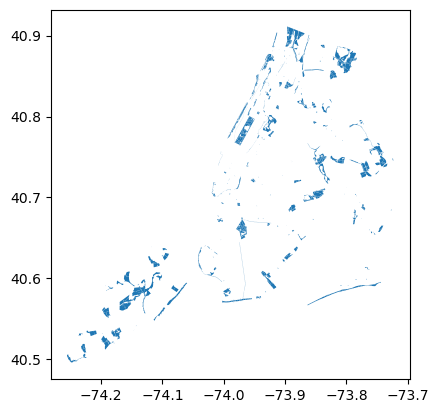

In [12]:
parks_shp.plot()